In [1]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

## Simulating data
We are simulating 23 average heights.

In [3]:
exercise02_df = pd.DataFrame({'Height': np.random.normal(170, 10, 23)})

## Model
Create a model in Stan for height data. We can assume that data can be described by a normal distribution: [normal(mu, sigma)](https://mc-stan.org/docs/functions-reference/unbounded_continuous_distributions.html#normal-distribution).

## Compiling the model

In [4]:
exercise02_model = cmdstanpy.CmdStanModel(stan_file="Stan/exercise02.stan")

## Preparing the data in Stan format

In [5]:
exercise02_standata = {
  'N' : len(exercise02_df),
  'Height' : exercise02_df.Height
}

## Sampling the model

In [6]:
exercise02_fit = exercise02_model.sample(
    data=exercise02_standata,
    chains=4,
    parallel_chains=os.cpu_count())

15:48:46 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
15:48:46 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:48:46 - cmdstanpy - INFO - CmdStan done processing.


## Extracting samples

In [7]:
exercise02_samples = exercise02_fit.draws_pd()

## Plot posterior distribution for attendance

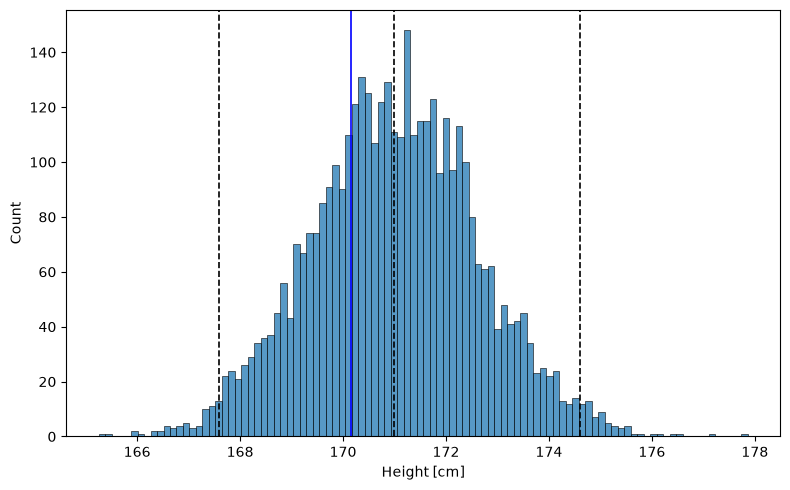

In [8]:
# compute 97% credible interval + median
mu_quantiles = np.quantile(exercise02_samples["mu"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(exercise02_samples["mu"], bins=100, stat="count")
for x in mu_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(exercise02_df.Height.mean(), color="blue", linestyle="-", linewidth=1.2)

plt.xlabel("Height [cm]")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Compute probability that average group height is above average height of 178

In [9]:
np.mean(exercise02_samples['mu']>178)

np.float64(0.0)